In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
dataset=pd.read_csv("Mall_Customers.csv")

In [3]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
x=dataset.iloc[:,[3,4]].values

In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

C:\Users\lenovo\anaconda3\envs\aiml\lib\site-packages\sklearn\neighbors\base.py:737: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(joblib_version) < LooseVersion('0.12'):
C:\Users\lenovo\anaconda3\envs\aiml\lib\site-packages\sklearn\neighbors\base.py:737: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(joblib_version) < LooseVersion('0.12'):


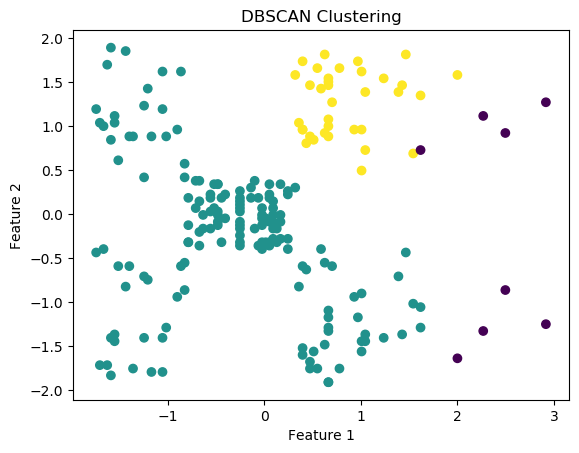

In [7]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.5 ,min_samples=5)
cluster=dbscan.fit_predict(x_scaled)
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=cluster)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [8]:
dataset['Cluster']=cluster
print(dataset.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


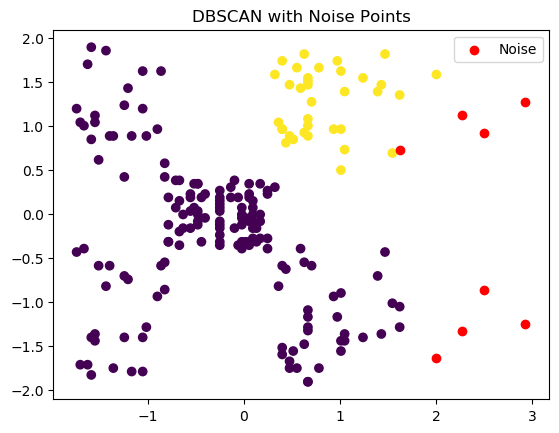

In [10]:
plt.scatter(x_scaled[dataset['Cluster'] != -1, 0],
            x_scaled[dataset['Cluster'] != -1, 1],
            c=dataset['Cluster'][dataset['Cluster'] != -1])

plt.scatter(x_scaled[dataset['Cluster'] == -1, 0],
            x_scaled[dataset['Cluster'] == -1, 1],
            color='red', label='Noise')

plt.legend()
plt.title("DBSCAN with Noise Points")
plt.show()